**Init**


In [ ]:
pip install pandas numpy scikit-learn tensorflow keras gensim underthesea matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00


**Download Stopwords**

In [ ]:
!wget https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt

--2026-06-02 03:21:15--  https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20475 (20K) [text/plain]
Saving to: ‘vietnamese-stopwords.txt’

vietnamese-stopword 100%[===================>]  20.00K  --.-KB/s    in 0.001s  

2026-06-02 03:21:15 (27.7 MB/s) - ‘vietnamese-stopwords.txt’ saved [20475/20475]



**Import Library**

In [129]:
import pandas as pd
import numpy as np
import tensorflow as tf
import ast
import re

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    SpatialDropout1D,
    BatchNormalization,
    Dense,
    Dropout,
    Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from underthesea import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns
import fasttext

**Load Dataset**

In [ ]:
DATA_PATH = "/content/merged_file (1).csv"
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (6474, 7)


,category,date,title,description,text,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


**Column Normalization**

In [ ]:
def standardize_columns(df_raw: pd.DataFrame):

    lower_map = {c.lower(): c for c in df_raw.columns}

    alias_candidates = {
        "title": ["title"],
        "summary": ["description"],
        "content": ["text"],
        "category": ["category"],
        "author": ["author"],
        "url": ["url"],
        "published_date": ["date"]
    }

    rename_map = {}

    for standard_col, aliases in alias_candidates.items():

        for alias in aliases:

            if alias in lower_map:
                rename_map[lower_map[alias]] = standard_col
                break

    df = df_raw.rename(columns=rename_map).copy()

    required_columns = [
        "title",
        "summary",
        "content",
        "category",
        "author",
        "url",
        "published_date"
    ]

    for col in required_columns:

        if col not in df.columns:
            df[col] = np.nan

    return df


df = standardize_columns(df_raw)
print("Current shape:", df.shape)
df.head()

Current shape: (6474, 7)


,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


**Clean Data and Remove Duplicate**

In [ ]:
def parse_tags(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if not s or s.lower() == "nan" or s == "[]":
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return list(dict.fromkeys([str(v).strip() for v in val if str(v).strip()]))
        except Exception:
            pass

    parts = [p.strip() for p in re.split(r",|;|\|", s) if p.strip()]
    return list(dict.fromkeys(parts))


def clean_basic_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


df["title"] = df["title"].fillna("").astype(str).map(clean_basic_text)
df["summary"] = df["summary"].fillna("").astype(str).map(clean_basic_text)
df["content"] = df["content"].fillna("").astype(str).map(clean_basic_text)
df["category"] = df["category"].fillna("").astype(str).str.strip()

before = len(df)

# Drop duplicate URL nếu có URL
if "url" in df.columns and df["url"].notna().any():
    df = df.drop_duplicates(subset=["url"])

# Drop duplicate title + summary
df = df.drop_duplicates(subset=["title", "summary"])

df = df[df["category"] != ""]

# Drop bài không có content/title đủ dùng
full_text = (df["title"] + " " + df["content"]).str.strip()
df = df[full_text.str.len() > 30].copy()

df = df.reset_index(drop=True)

print(f"Before clean: {before:,}")
print(f"After clean:  {len(df):,}")

eda = pd.DataFrame({
    "n_articles": [len(df)],
    "n_categories": [df["category"].replace("", np.nan).nunique()],
    "missing_content": [(df["content"].str.len() == 0).sum()],
    "missing_summary": [(df["summary"].str.len() == 0).sum()],
    "missing_title": [(df["title"].str.len() == 0).sum()],
    "missing_url": [(df["url"].str.len() == 0).sum()],
})
display(eda)

print("Top categories")
display(df["category"].value_counts().head(20))

Before clean: 6,474
After clean:  6,428


,n_articles,n_categories,missing_content,missing_summary,missing_title,missing_url
0,6428,21,37,8,0,0


Top categories


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


**Clean the critical columns**

In [ ]:
text_columns = ["title", "summary", "content"]

for col in text_columns:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .apply(clean_basic_text)
    )

df["category"] = (
    df["category"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["url"] = (
    df["url"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df.head()

,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


**Remove invalid posts (< 30 words)**

In [ ]:
df["combined_text"] = (
    df["title"] + " " +
    df["summary"] + " " +
    df["content"]
)

df["combined_text"] = df["combined_text"].apply(clean_basic_text)

# Remove short articles
df = df[df["combined_text"].str.len() > 30]

df = df.reset_index(drop=True)

print("Final dataset size:", len(df))

Final dataset size: 6428


**Vietnamese Preprocessing**

In [ ]:
with open("vietnamese-stopwords.txt", "r", encoding="utf-8") as f:
    VI_STOPWORDS = set(
        line.strip()
        for line in f
    )

print("Total stopwords:", len(VI_STOPWORDS))

Total stopwords: 1942


**Tokenize**

In [ ]:
def vi_tokenize(text):
    return word_tokenize(text, format="text")

**Normalize Text**

In [ ]:
def normalize_text(text):
    # Basic cleaning
    text = clean_basic_text(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remove special characters
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ_\s]", " ", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return ""
    # Vietnamese tokenization
    text = vi_tokenize(text)
    tokens = []
    for token in text.split():
        token = token.strip()
        # Remove empty token
        if not token:
            continue
        # Remove short token
        if len(token) < 2 and not token.isdigit():
            continue
        # Remove stopwords
        if token in VI_STOPWORDS:
            continue
        tokens.append(token)

    return " ".join(tokens)

**Apply Processing**

In [ ]:
df["clean_text"] = df["combined_text"].apply(normalize_text)
print("Preprocessing completed.")
df[["combined_text", "clean_text"]].head()

Preprocessing completed.


,combined_text,clean_text
0,Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm H...,giá đất gấp 2 3 hiệu_ứng khu đô_thị lấn biển k...
1,"Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...",trai chuẩn_bị mì tôm_xúc xích đi du_lịch chi_p...
2,"Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...",phân_biệt sốc_nhiệt bệnh hô_hấp tiêu_hóa trẻ g...
3,Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,chi 400 triệu đồng cải_tạo căn_hộ wabi sabi vợ...
4,6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,6 cây_cảnh trồng căn_hộ ánh_sáng hồng môn trúc...


**Remove labels (< 10 samples)**

In [ ]:
MIN_SAMPLES = 10

category_counts = df["category"].value_counts()

valid_categories = category_counts[
    category_counts >= MIN_SAMPLES
].index

df = df[
    df["category"].isin(valid_categories)
].copy()

df.reset_index(drop=True, inplace=True)

print("Remaining classes:", df["category"].nunique())
print("Remaining samples:", len(df))

display(df["category"].value_counts())

Remaining classes: 14
Remaining samples: 6412


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


**EDA**

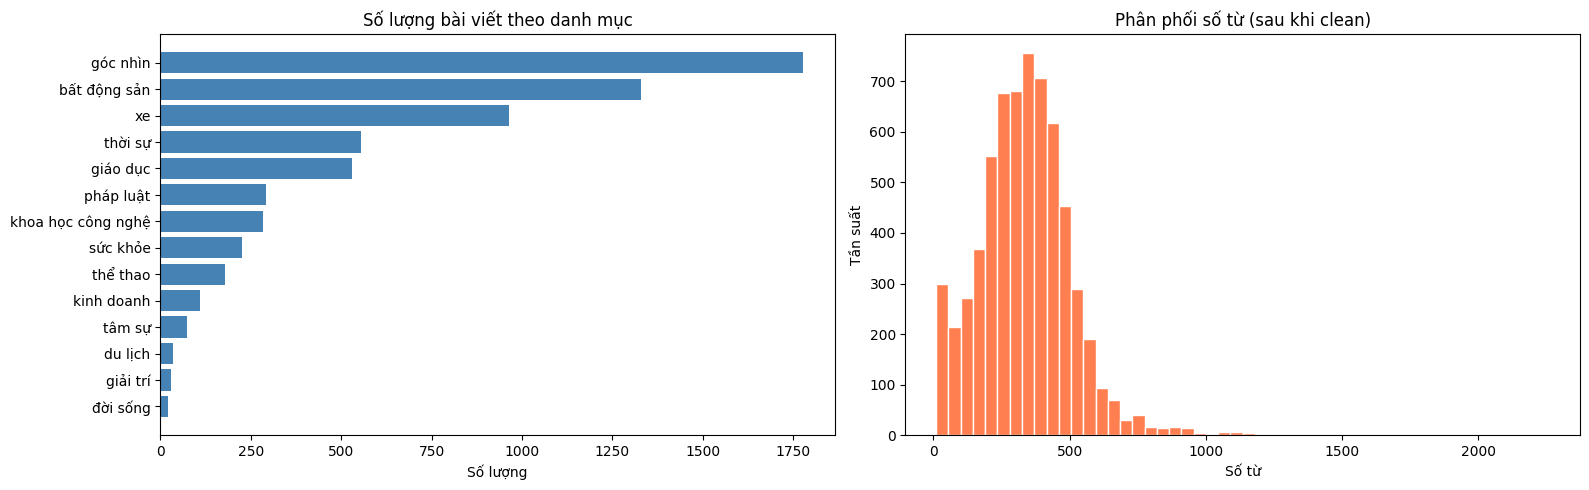


Thống kê độ dài văn bản (số token):
count    6412.000000
mean      337.823144
std       174.796763
min        10.000000
25%       227.000000
50%       334.000000
75%       436.000000
max      2262.000000
Name: clean_text, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Phân phối danh mục ---
cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[0].set_title("Số lượng bài viết theo danh mục")
axes[0].set_xlabel("Số lượng")

# --- Phân phối độ dài văn bản ---
token_len = df["clean_text"].apply(lambda x: len(x.split()))
axes[1].hist(token_len, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Phân phối số từ (sau khi clean)")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

print("\nThống kê độ dài văn bản (số token):")
print(token_len.describe())

**Label Encoding**

In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["category"]
)

print("Classes:", label_encoder.classes_)
print()

print(df[["category", "label"]].head())

print("\nLabel Mapping:")

for i, category in enumerate(label_encoder.classes_):
    print(f"{i} --> {category}")

Classes: ['bất động sản' 'du lịch' 'giáo dục' 'giải trí' 'góc nhìn'
 'khoa học công nghệ' 'kinh doanh' 'pháp luật' 'sức khỏe' 'thể thao'
 'thời sự' 'tâm sự' 'xe' 'đời sống']

       category  label
0  bất động sản      0
1        tâm sự     11
2      sức khỏe      8
3  bất động sản      0
4  bất động sản      0

Label Mapping:
0 --> bất động sản
1 --> du lịch
2 --> giáo dục
3 --> giải trí
4 --> góc nhìn
5 --> khoa học công nghệ
6 --> kinh doanh
7 --> pháp luật
8 --> sức khỏe
9 --> thể thao
10 --> thời sự
11 --> tâm sự
12 --> xe
13 --> đời sống


**Train & Test Data**

In [ ]:
# Bước 1: tách 80% train, 20% còn lại
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Bước 2: chia tiếp 20% đó thành 10% val + 10% test
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 5129
Validation: 641
Test: 642


**Class Weight**

In [106]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, w in class_weight_dict.items():
    print(f"  {label_encoder.classes_[i]:<25} {w:.2f}")

Class weights:
  bất động sản              0.34
  du lịch                   12.63
  giáo dục                  0.86
  giải trí                  15.26
  góc nhìn                  0.26
  khoa học công nghệ        1.61
  kinh doanh                4.16
  pháp luật                 1.57
  sức khỏe                  2.02
  thể thao                  2.54
  thời sự                   0.82
  tâm sự                    6.32
  xe                        0.47
  đời sống                  21.55


# **FastText**

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653906 sha256=b1fe1973c5349fae6d2e04b0374c712d24d78f50f7aedbe3c8f4ec921a74e71d
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
# Ghi corpus ra file để FastText đọc
with open("fasttext_corpus.txt", "w", encoding="utf8") as f:
    for text in X_train_text:
        f.write(text + "\n")

print("Corpus saved:", len(X_train_text), "documents")

Corpus saved: 5129 documents


In [ ]:
# Huấn luyện FastText với tham số tối ưu
# - model="skipgram": phù hợp cho từ hiếm và OOV (out-of-vocabulary)
# - dim=200: cân bằng giữa chất lượng embedding và tốc độ
# - epoch=20: số lần duyệt corpus đủ để học tốt
# - lr=0.05: learning rate mặc định ổn định cho skipgram
# - wordNgrams=2: nắm bắt cụm từ 2 từ liên tiếp (e.g., "bất_động_sản")
# - minCount=2: bỏ từ xuất hiện < 2 lần (giảm nhiễu)
# - minn=2, maxn=5: subword n-gram bắt được biến thể hình thái học
fasttext_model = fasttext.train_unsupervised(
    "fasttext_corpus.txt",
    model="skipgram",
    dim=200,
    epoch=20,
    lr=0.05,
    wordNgrams=2,
    minCount=2,
    minn=2,
    maxn=5,
    thread=4
)

print("FastText training complete.")
print("Vocabulary size:", len(fasttext_model.words))

FastText training complete.
Vocabulary size: 31028


**Save model FastText**

In [ ]:
fasttext_model.save_model("fasttext_model.bin")

In [ ]:
# Load lại file FastText đã train
fasttext_model = fasttext.load_model(
    "/content/fasttext_model.bin"
)

print("FastText model loaded.")

FastText model loaded.


In [ ]:
# Kiểm tra embedding vector
vec = fasttext_model.get_word_vector("bóng_đá")
print("Vector dim:", vec.shape)
print("Sample vector:", vec[:5])

Vector dim: (200,)
Sample vector: [-0.2143933  -0.09792059  0.49697927  0.21337467 -0.33328995]


**Keras Tokenizer**

In [ ]:
# MAX_WORDS: giữ 30000 từ phổ biến nhất (dữ liệu ~6k docs, không cần quá lớn)
MAX_WORDS = 30000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(X_train_text)

print("Vocab size (raw):", len(tokenizer.word_index))
print("Effective vocab (MAX_WORDS):", MAX_WORDS)

Vocab size (raw): 21117
Effective vocab (MAX_WORDS): 30000


**Text2Sequences**

In [ ]:
# Chuyển văn bản -> sequence

X_train_seq = tokenizer.texts_to_sequences(X_train_text)

X_val_seq = tokenizer.texts_to_sequences(X_val_text)

X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Thống kê độ dài sequence trên tập train
seq_lens = [len(seq) for seq in X_train_seq]

print("Sequence length statistics (Train Set)")
display(pd.Series(seq_lens).describe())

# Percentiles để chọn MAX_LEN hợp lý
print("\nPercentiles:")
print("90% :", np.percentile(seq_lens, 90))
print("95% :", np.percentile(seq_lens, 95))
print("99% :", np.percentile(seq_lens, 99))

Sequence length statistics (Train Set)


,0
count,5129.000000
mean,537.917138
std,283.502994
min,15.000000
25%,350.000000
50%,529.000000
75%,708.000000
max,3183.000000



Percentiles:
90% : 859.1999999999998
95% : 969.5999999999995
99% : 1362.7200000000003


**Padding String**

In [ ]:
lengths = df["clean_text"].apply(lambda x: len(x.split()))

print("Token length stats (full dataset):")
print(lengths.describe())

# Chọn MAX_LEN = percentile 90 để tránh padding quá nhiều
MAX_LEN = int(lengths.quantile(0.90))
print(f"\nChọn MAX_LEN = {MAX_LEN} (90th percentile)")

Token length stats (full dataset):
count    6412.000000
mean      337.823144
std       174.796763
min        10.000000
25%       227.000000
50%       334.000000
75%       436.000000
max      2262.000000
Name: clean_text, dtype: float64

Chọn MAX_LEN = 531 (90th percentile)


In [ ]:
# Padding sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:  ", X_val_pad.shape)
print("X_test_pad shape: ", X_test_pad.shape)

X_train_pad shape: (5129, 531)
X_val_pad shape:   (641, 531)
X_test_pad shape:  (642, 531)


**Embedding FastText**

In [ ]:
EMBEDDING_DIM = 200  # Phải khớp với dim khi train FastText

word_index  = tokenizer.word_index
vocab_size  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    vec = fasttext_model.get_word_vector(word)
    embedding_matrix[idx] = vec
    found += 1

coverage = found / vocab_size * 100
print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words covered by FastText: {found}/{vocab_size} ({coverage:.1f}%)")

Embedding matrix shape : (21118, 200)
Words covered by FastText: 21117/21118 (100.0%)


**Change the label to One-hot**

In [ ]:
num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(
    y_train,
    num_classes=num_classes
)

y_val_cat = to_categorical(
    y_val,
    num_classes=num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes=num_classes
)

print("Number of classes:", num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:  ", y_val_cat.shape)
print("y_test_cat shape: ", y_test_cat.shape)

Number of classes: 14
y_train_cat shape: (5129, 14)
y_val_cat shape:   (641, 14)
y_test_cat shape:  (642, 14)


# **Basic CNN**

In [197]:
model_basic = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True
    ),
    SpatialDropout1D(0.3),

    Conv1D(filters=128, kernel_size=5, activation="relu", padding="same"),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    GlobalMaxPooling1D(),

    BatchNormalization(),
    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(num_classes, activation="softmax")
], name="CNN_Basic")

model_basic.summary()

Model: "CNN_Basic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 531, 200)       │     4,223,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_14            │ (None, 531, 200)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 531, 128)       │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 265, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 265, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,694 (16.71 MB)

 Trainable params: 4,381,566 (16.71 MB)

 Non-trainable params: 128 (512.00 B)

**Compile CNN**

In [198]:
model_basic.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**Callbacks**

In [199]:
callbacks_basic = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_cnn_basic.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

**Train CNN Basic**

In [200]:
history_basic = model_basic.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30, batch_size=64,
    callbacks=callbacks_basic,
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3212 - loss: 2.2452
Epoch 1: val_accuracy improved from None to 0.50858, saving model to best_cnn_basic.keras

Epoch 1: finished saving model to best_cnn_basic.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.4707 - loss: 1.7682 - val_accuracy: 0.5086 - val_loss: 1.4993 - learning_rate: 0.0010
Epoch 2/30
78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6886 - loss: 1.0498
Epoch 2: val_accuracy improved from 0.50858 to 0.83931, saving model to best_cnn_basic.keras

Epoch 2: finished saving model to best_cnn_basic.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7151 - loss: 0.9700 - val_accuracy: 0.8393 - val_loss: 0.9050 - learning_rate: 0.0010
Epoch 3/30
79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7872 - loss: 0.7625
Epoch 3: val_accuracy did not improve from 0.83931
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8002 - loss: 0.7136 - val_accuracy: 0.8253 - val_loss: 0.6079 - 

**Evaluate CNN**

In [201]:
loss, acc = model_basic.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Test Loss    : 0.3305
Test Accuracy: 0.9252 (92.52%)


**Classification Report**

In [202]:
pred_prob = model_basic.predict(X_test_pad, verbose=0)
pred      = np.argmax(pred_prob, axis=1)

# --- Classification Report ---
print("=" * 55)
print("          CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_test,
    pred,
    target_names=label_encoder.classes_,
    digits=4
))

# --- Tổng hợp các chỉ số ---
f1        = f1_score(y_test, pred, average="macro")
precision = precision_score(y_test, pred, average="macro")
recall    = recall_score(y_test, pred, average="macro")

print("-" * 40)
print(f"Macro F1 Score       : {f1:.4f}")
print(f"Macro Precision      : {precision:.4f}")
print(f"Macro Recall         : {recall:.4f}")
print(f"Overall Accuracy     : {accuracy_score(y_test, pred):.4f}")

          CLASSIFICATION REPORT
                    precision    recall  f1-score   support

      bất động sản     0.9615    0.9398    0.9506       133
           du lịch     0.0000    0.0000    0.0000         3
          giáo dục     0.9412    0.9057    0.9231        53
          giải trí     0.0000    0.0000    0.0000         3
          góc nhìn     0.9716    0.9607    0.9661       178
khoa học công nghệ     0.9231    0.8571    0.8889        28
        kinh doanh     1.0000    0.3636    0.5333        11
         pháp luật     0.9062    0.9667    0.9355        30
          sức khỏe     0.9583    1.0000    0.9787        23
          thể thao     1.0000    0.9444    0.9714        18
           thời sự     0.7576    0.8929    0.8197        56
            tâm sự     0.8571    0.8571    0.8571         7
                xe     0.8899    1.0000    0.9417        97
          đời sống     0.0000    0.0000    0.0000         2

          accuracy                         0.9252       642
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

**Confusion Matrix**

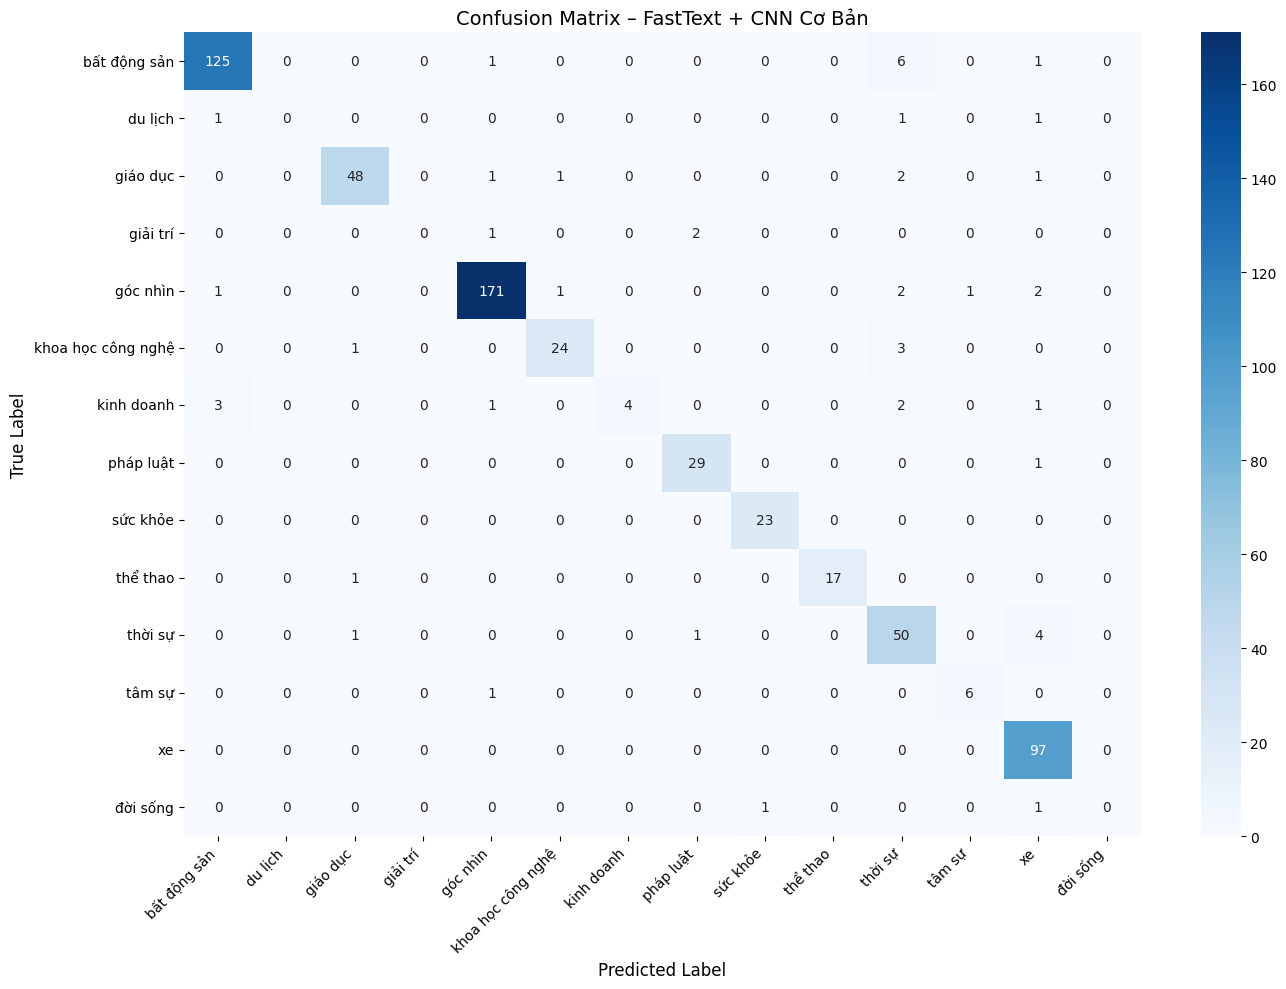

In [203]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – FastText + CNN Cơ Bản", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Training Curves**

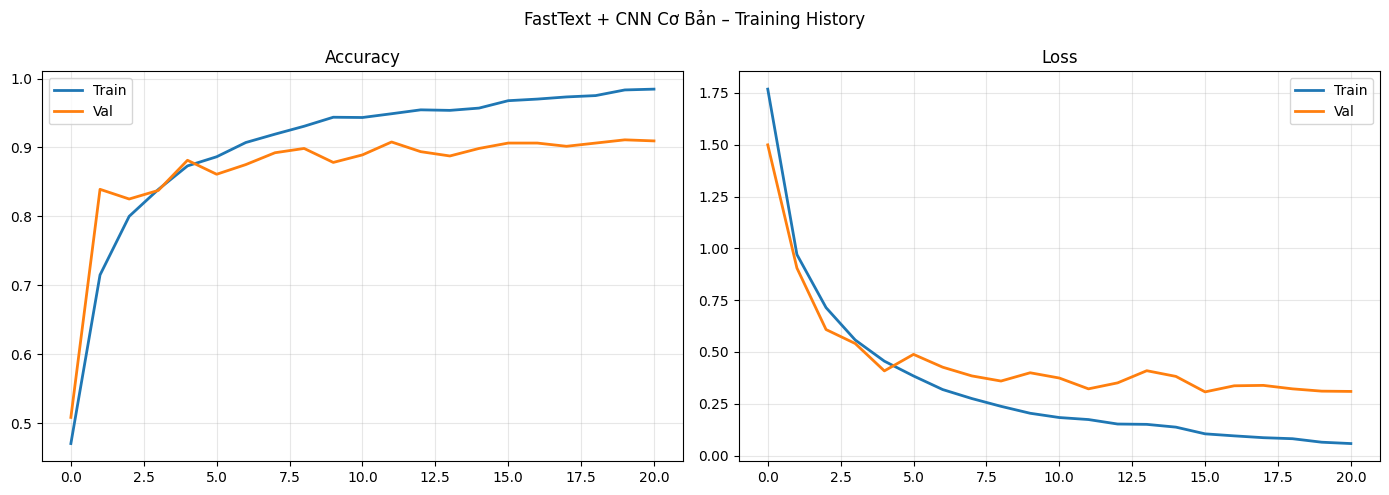

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_basic.history["accuracy"],     label="Train", lw=2)
axes[0].plot(history_basic.history["val_accuracy"], label="Val",   lw=2)
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_basic.history["loss"],     label="Train", lw=2)
axes[1].plot(history_basic.history["val_loss"], label="Val",   lw=2)
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("FastText + CNN Cơ Bản – Training History")
plt.tight_layout(); plt.show()

**Result**

In [205]:
pred_basic = np.argmax(model_basic.predict(X_test_pad, verbose=0), axis=1)
acc_basic  = accuracy_score(y_test, pred_basic)
f1_basic   = f1_score(y_test, pred_basic, average="macro")
print(f"CNN Basic — Acc: {acc_basic:.4f} | F1: {f1_basic:.4f}")

CNN Basic — Acc: 0.9252 | F1: 0.6976


**Save Model**

In [206]:
model_basic.save("fasttext_cnn_basic.keras")
print("Saved: fasttext_cnn_basic.keras")

Saved: fasttext_cnn_basic.keras


# **Multi-Kernel CNN**

In [186]:
# ── MULTI-KERNEL CNN (Kim 2014) ──────────────────────────────
#
# 3 nhánh song song với kernel_size khác nhau:
#   kernel=2 → cụm 2 từ: "bất động", "sức khỏe"
#   kernel=3 → cụm 3 từ: "bất động sản", "tai nạn giao thông"
#   kernel=5 → cụm 5 từ: ngữ cảnh rộng hơn
# Sau đó Concatenate 3 nhánh → Dense → Softmax
#
#  Embedding ──┬── Conv1D(k=2) ── GMP ──┐
#              ├── Conv1D(k=3) ── GMP ──┤── Concat ── BN ── Dense ── Output
#              └── Conv1D(k=5) ── GMP ──┘

KERNEL_SIZES = [2, 3, 5]
NUM_FILTERS  = 64   # nhỏ để tránh overfit với ~6k mẫu

inp = Input(shape=(MAX_LEN,), name="input")

emb = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=True,
    name="fasttext_embedding"
)(inp)
emb = SpatialDropout1D(0.3)(emb)

branches = []
for ks in KERNEL_SIZES:
    x = Conv1D(filters=NUM_FILTERS, kernel_size=ks,
               activation="relu", padding="same",
               name=f"conv_k{ks}")(emb)
    x = GlobalMaxPooling1D(name=f"gmp_k{ks}")(x)
    branches.append(x)

merged = Concatenate(name="concat")(branches)  # 64*3 = 192 features

x = BatchNormalization(name="bn")(merged)
x = Dense(128, activation="relu", name="fc1")(x)
x = Dropout(0.4, name="dropout")(x)
out = Dense(num_classes, activation="softmax", name="output")(x)

model_mk = Model(inputs=inp, outputs=out, name="MultiKernel_CNN")
model_mk.summary()

Model: "MultiKernel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 531)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fasttext_embedding  │ (None, 531, 200)  │  4,223,600 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 531, 200)  │          0 │ fasttext_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k2 (Conv1D)    │ (None, 531, 64)   │     25,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 531, 64)   │     38,464 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 531, 64)   │     64,064 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_k2              │ (None, 64)        │          0 │ conv_k2[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_k3              │ (None, 64)        │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp_k5              │ (None, 64)        │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ gmp_k2[0][0],     │
│ (Concatenate)       │                   │            │ gmp_k3[0][0],     │
│                     │                   │            │ gmp_k5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn                  │ (None, 192)       │        768 │ concat[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 128)       │     24,704 │ bn[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 14)        │      1,806 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,379,070 (16.70 MB)

 Trainable params: 4,378,686 (16.70 MB)

 Non-trainable params: 384 (1.50 KB)

**Compile Multi-Kernel CNN**

In [187]:
model_mk.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**Callbacks**

In [188]:
callbacks_mk = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_cnn_mk.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

**Train**

In [189]:
history_mk = model_mk.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30, batch_size=64,
    callbacks=callbacks_mk,
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3786 - loss: 2.1812
Epoch 1: val_accuracy improved from None to 0.44150, saving model to best_cnn_mk.keras

Epoch 1: finished saving model to best_cnn_mk.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.5329 - loss: 1.6444 - val_accuracy: 0.4415 - val_loss: 1.5908 - learning_rate: 0.0010
Epoch 2/30
78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7332 - loss: 0.9037
Epoch 2: val_accuracy improved from 0.44150 to 0.84087, saving model to best_cnn_mk.keras

Epoch 2: finished saving model to best_cnn_mk.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7557 - loss: 0.8217 - val_accuracy: 0.8409 - val_loss: 0.5882 - learning_rate: 0.0010
Epoch 3/30
79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8342 - loss: 0.5654
Epoch 3: val_accuracy improved from 0.84087 to 0.86739, saving model to best_cnn_mk.keras

Epoch 3: finished saving model to best_cnn_mk.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/st

**Evaluate**

In [190]:
loss, acc = model_mk.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Test Loss    : 0.2461
Test Accuracy: 0.9299 (92.99%)


**Classification Report**

In [191]:
pred_prob_mk = model_mk.predict(X_test_pad, verbose=0)
pred_mk      = np.argmax(pred_prob_mk, axis=1)

# --- Classification Report ---
print("=" * 55)
print("          CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_test,
    pred_mk,
    target_names=label_encoder.classes_,
    digits=4
))

# --- Tổng hợp các chỉ số ---
f1        = f1_score(y_test, pred_mk, average="macro")
precision = precision_score(y_test, pred_mk, average="macro")
recall    = recall_score(y_test, pred_mk, average="macro")

print("-" * 40)
print(f"Macro F1 Score       : {f1:.4f}")
print(f"Macro Precision      : {precision:.4f}")
print(f"Macro Recall         : {recall:.4f}")
print(f"Overall Accuracy     : {accuracy_score(y_test, pred_mk):.4f}")

          CLASSIFICATION REPORT
                    precision    recall  f1-score   support

      bất động sản     0.9630    0.9774    0.9701       133
           du lịch     0.0000    0.0000    0.0000         3
          giáo dục     0.9259    0.9434    0.9346        53
          giải trí     0.0000    0.0000    0.0000         3
          góc nhìn     0.9940    0.9326    0.9623       178
khoa học công nghệ     0.8276    0.8571    0.8421        28
        kinh doanh     0.7500    0.5455    0.6316        11
         pháp luật     0.8750    0.9333    0.9032        30
          sức khỏe     0.9200    1.0000    0.9583        23
          thể thao     1.0000    1.0000    1.0000        18
           thời sự     0.8305    0.8750    0.8522        56
            tâm sự     0.8750    1.0000    0.9333         7
                xe     0.9057    0.9897    0.9458        97
          đời sống     0.0000    0.0000    0.0000         2

          accuracy                         0.9299       642
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

**Confusion Matrix**

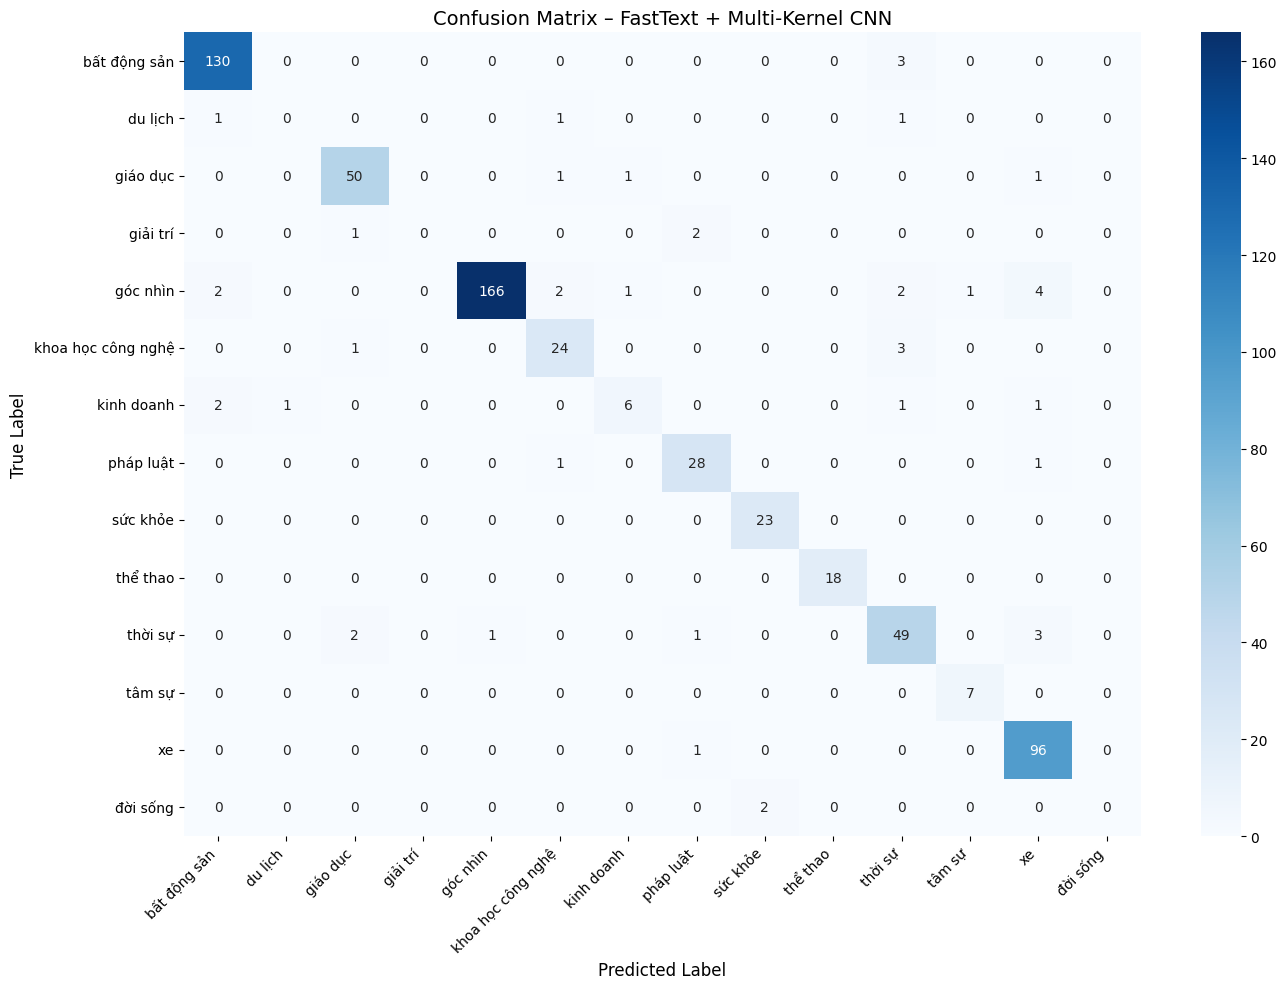

In [192]:
cm = confusion_matrix(y_test, pred_mk)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – FastText + Multi-Kernel CNN", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Training Curves**

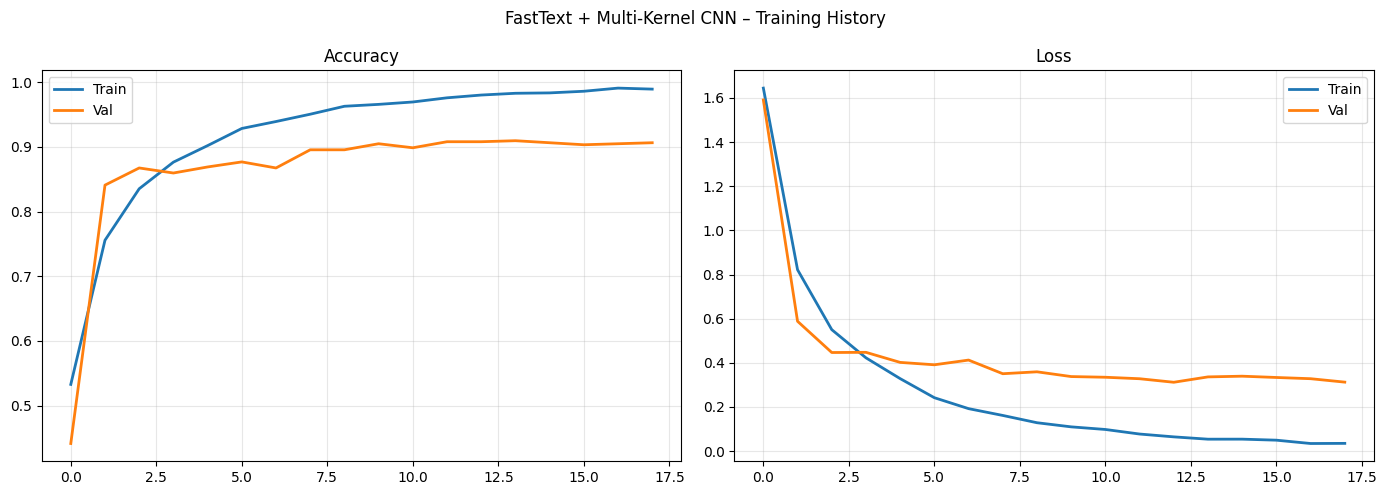

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_mk.history["accuracy"],     label="Train", lw=2)
axes[0].plot(history_mk.history["val_accuracy"], label="Val",   lw=2)
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_mk.history["loss"],     label="Train", lw=2)
axes[1].plot(history_mk.history["val_loss"], label="Val",   lw=2)
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("FastText + Multi-Kernel CNN – Training History")
plt.tight_layout(); plt.show()

**Result**

In [194]:
pred_mk = np.argmax(model_mk.predict(X_test_pad, verbose=0), axis=1)
acc_mk  = accuracy_score(y_test, pred_mk)
f1_mk   = f1_score(y_test, pred_mk, average="macro")
print(f"Multi-Kernel CNN — Acc: {acc_mk:.4f} | F1: {f1_mk:.4f}")

Multi-Kernel CNN — Acc: 0.9299 | F1: 0.7095


**Save Model**

In [195]:
model_mk.save("best_cnn_mk.keras")
print("Saved: best_cnn_mk.keras")

Saved: best_cnn_mk.keras


# **Compare**

In [207]:
comparison = pd.DataFrame({
    "Model": ["CNN Cơ Bản", "Multi-Kernel CNN (Kim 2014)"],
    "Test Accuracy": [acc_basic, acc_mk],
    "Macro F1":      [f1_basic,  f1_mk],
})
comparison["Test Accuracy"] = comparison["Test Accuracy"].map("{:.4f}".format)
comparison["Macro F1"]      = comparison["Macro F1"].map("{:.4f}".format)

print("=" * 50)
print("         SO SÁNH 2 MÔ HÌNH")
print("=" * 50)
display(comparison)

winner = "Multi-Kernel CNN" if f1_mk > f1_basic else "CNN Cơ Bản"
print(f"\nModel tốt hơn: {winner}")

         SO SÁNH 2 MÔ HÌNH


,Model,Test Accuracy,Macro F1
0,CNN Cơ Bản,0.9252,0.6976
1,Multi-Kernel CNN (Kim 2014),0.9299,0.7095



Model tốt hơn: Multi-Kernel CNN


# **Inference**

In [208]:
# Chọn model tốt hơn để inference
best_model = model_mk if f1_mk >= f1_basic else model_basic

def predict_category(text: str, top_k: int = 3):
    cleaned = normalize_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    probs   = best_model.predict(padded, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(label_encoder.classes_[i], float(probs[i])) for i in top_idx]

sample = "PGS. TS Nguyễn Tấn Trần Minh Khang giữ chức hiệu trưởng Đại học Công nghệ Thông tin"
print(f"Văn bản: {sample}\n")
for cat, prob in predict_category(sample):
    print(f"  {cat:<25} {prob:.4f}  {'█' * int(prob * 30)}")

Văn bản: PGS. TS Nguyễn Tấn Trần Minh Khang giữ chức hiệu trưởng Đại học Công nghệ Thông tin

  giáo dục                  0.9995  █████████████████████████████
  khoa học công nghệ        0.0004  
  thời sự                   0.0001  


Tài liệu tham khảo (References)


1.   Kim, Y. (2014). Convolutional Neural Networks for Sentence Classification. Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP), 1746–1751.
2.   Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). Enriching Word Vectors with Subword Information. Transactions of the Association for Computational Linguistics, 5, 135–146.
3. NTLK / Underthesea Documentation - Vietnamese Word Segmentation.

